Notebook 2c: BART fine-tuned as a denoiser

BART is a sequence-to-sequence model pretrained to reconstruct text that was corrupted on purpose (a denoising
autoencoder). Here `facebook/bart-base` is fine-tuned to do exactly our task: it reads a damaged sentence and
writes it back repaired. It reads the same slot view as the other methods (context words as they are, each
damaged word in brackets, a missing word as `{ ? }`) and writes the sentence back with its answer in each
bracket; the answers are read from the brackets.

**What differs from BERT and the LLM, and why it matters.** BERT is fine-tuned on clean text only and sees the
damaged letters only through its reranking score; the LLM is not trained at all. BART is trained on damaged
text, made by the same damage generator and settings as the evaluation data. It is the "supervised on the noise
process" way to repair, and its result is likely an optimistic estimate of what such a model would do on real
damage, where the noise differs from the training noise.

**Input.** `data/processed/corrupted_v2.jsonl` (hash checked), the training record of `scripts/train_bart.py`
(`runs/bart_ft_v1_log.csv`, `runs/bart_ft_v1_config.yaml`, `runs/bart_ft_v1_val_outputs.jsonl`), the model
`models/bart_ft_v1/` (hash checked, only to confirm it is the trained one; nothing is generated here), the stored
repairs `runs/preds/bart_<version>.jsonl`, `configs/bart_ft.yaml` and `configs/bart_repair.yaml`.

**Output.** The training curves and the dev check below. Training and repair ran on a rented GPU (RunPod, NVIDIA
A40) with `scripts/pod/pod.sh`, because they do not fit on the laptop; the notebook only reads what they wrote.

In [1]:
import json

import pandas as pd
import yaml

from blnrepair.bart_data import (bart_input, bart_target, bart_version, bart_view, damaged_record,
                                 load_bart_repair_config)
from blnrepair.bert_train import sha256_file
from blnrepair.corrupt import load_table, settings
from blnrepair.data import ROOT, load_config
from blnrepair.freeze import load_frozen
from blnrepair.plots import fit_curves
from blnrepair.preds import load_preds, pred_path, slot_exact
from blnrepair.slots import build_slots, slot_view

pd.set_option("display.max_colwidth", None)
config, repair_cfg = load_config(), load_bart_repair_config()
rows = load_frozen("v2")  # stops if the file hash does not match runs/corrupted_v2.sha256
run = yaml.safe_load((ROOT / "runs" / "bart_ft_v1_config.yaml").read_text(encoding="utf-8"))

The input and the answer

The same dev row as the other methods see it (slot view), as BART sees it, and a training target. Only the
bracket characters differ: BART's tokenizer cuts `⟨` and `⟩` into three byte pieces each and glues the word to
them, so BART gets `{ word }`, which keeps every slot a normal word. No BLN600 sentence contains `{` or `}`.

In [2]:
row = next(r for r in rows if r["split"] == "dev" and r["severity"] == "25")
view = build_slots(row)
print("slot view (BERT, LLM):", slot_view(view))
print("BART input:           ", bart_view(view))
print("gold:                 ", row["gold_text"])

slot view (BERT, LLM): It was ascertained that he had hired a bicycle at Aberdeen, and had ridden from there to Perth, where, it was asserted, he ⟨so1d⟩ ⟨tbe⟩ ⟨icyclc⟩ ⟨tor⟩ ⟨£1,⟩ ⟨aud⟩ ⟨bhen⟩ ⟨eame⟩ ⟨bo⟩ London with the money.
BART input:            It was ascertained that he had hired a bicycle at Aberdeen, and had ridden from there to Perth, where, it was asserted, he { so1d } { tbe } { icyclc } { tor } { £1, } { aud } { bhen } { eame } { bo } London with the money.
gold:                  It was ascertained that he had hired a bicycle at Aberdeen, and had ridden from there to Perth, where, it was asserted, he sold the bicycle for £2, and then came to London with the money.


Training data

The sentences of the BERT training pool (443 excerpts outside the sample, split by excerpt into training and
validation sentences). Every epoch damages every training sentence again at all five levels, with a new anchor
and new damage, so each level has the same weight, as in the evaluation. The target is the gold sentence with
each damaged word in brackets. One training sentence at level 25, drawn for epoch 0:

In [3]:
calibration = json.loads((ROOT / "reports" / "calibration.json").read_text(encoding="utf-8"))
pool = pd.read_json(ROOT / "data" / "processed" / "bert_train_pool.jsonl", lines=True).to_dict("records")
example = damaged_record(next(r for r in pool if r["usage"] == "train"), "25", "0", load_table(calibration),
                         settings(config, calibration))
print("input: ", bart_input(example))
print("target:", bart_target(example))
pd.Series({"training examples per epoch": run["n_train_examples_per_epoch"], "validation examples": run["n_val_examples"],
           "probe examples": run["n_probe_examples"], "steps per epoch": run["steps_per_epoch"]})

input:  EDWARD PRING, twenty-seven, carpenter, was brought up on remand at the Greenwich Police-court, charged with stealing jewellery { te } { ? } { vale } { ot } { £10O, } { tlie } { projetty } { ot } { Eir } Robert Cunliffe, Bart., M.P., of 37 Lowndes street, Belgravia.
target: EDWARD PRING, twenty-seven, carpenter, was brought up on remand at the Greenwich Police-court, charged with stealing jewellery { to } { the } { value } { of } { £100, } { the } { property } { of } { Sir } Robert Cunliffe, Bart., M.P., of 37 Lowndes street, Belgravia.


training examples per epoch    13175
validation examples             1520
probe examples                  1520
steps per epoch                  824
dtype: int64

Fine-tuning record

Settings as for BERT wherever the two models allow it (`configs/bart_ft.yaml`): learning rate 5e-5, batch 16,
at most 10 epochs, early stopping after 2 epochs without a lower validation loss, warmup over 10% of one epoch,
weight decay 0.01, bfloat16 on the GPU. The checkpoint with the lowest validation loss is kept.

After every epoch the model is measured on two fixed sets. **Validation**: sentences it never trained on.
**Probe**: as many training sentences, with a damage draw no epoch used. If the probe is clearly better than
validation, the model has learnt the training sentences themselves (overfitting); if both stay poor, it has
learnt too little (underfitting). Epoch 0 is `bart-base` before fine-tuning. Decoding is greedy and fixed before
any dev run: nothing is tuned on dev.

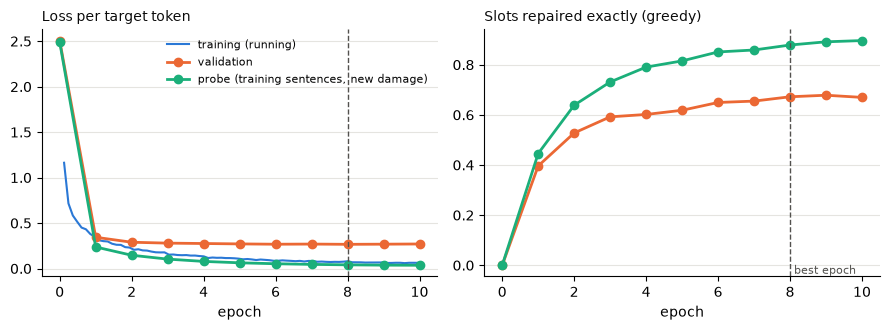

In [4]:
log = pd.read_csv(ROOT / "runs" / "bart_ft_v1_log.csv")
fig = fit_curves(log, run["best_epoch"])

In [5]:
per_epoch = log[log["kind"] != "train"].pivot(index="epoch", columns="kind", values=["loss", "slot_exact", "format_failures"])
print(f"{run['stop_reason']}; best epoch {run['best_epoch']}, {run['minutes']} min on {run['device']}")
per_epoch.round(3)

early stop: no lower validation loss for 2 epochs; best epoch 8, 22.5 min on NVIDIA A40


loss        slot_exact        format_failures       
kind   probe    val      probe    val           probe    val
epoch                                                       
0      2.489  2.507      0.000  0.000           276.0  239.0
1      0.237  0.344      0.446  0.396           247.0  279.0
2      0.146  0.289      0.639  0.528           141.0  175.0
3      0.104  0.279      0.731  0.592            99.0  126.0
4      0.079  0.275      0.791  0.602            70.0  130.0
5      0.063  0.271      0.815  0.618            63.0  111.0
6      0.053  0.267      0.851  0.649            52.0   90.0
7      0.046  0.269      0.859  0.655            55.0   87.0
8      0.041  0.266      0.879  0.672            40.0   78.0
9      0.037  0.268      0.891  0.678            33.0   71.0
10     0.036  0.270      0.896  0.670            32.0   76.0

In [6]:
levels = [c for c in log.columns if c.startswith("exact_")]
best = log[(log["epoch"] == run["best_epoch"]) & (log["kind"].isin(["val", "probe"]))].set_index("kind")[levels]
best.columns = [c.removeprefix("exact_") for c in levels]
print(f"slots repaired exactly per level at the best epoch ({run['best_epoch']})")
best.round(3)

slots repaired exactly per level at the best epoch (8)


,1w,10,25,50,75
kind,,,,,
val,0.556,0.710,0.724,0.695,0.639
probe,0.941,0.932,0.915,0.900,0.842


In [7]:
digest = sha256_file(ROOT / repair_cfg["model"] / "model.safetensors")
assert digest == run["model_sha256"], "models/bart_ft_v1 is not the model of this training record"
print(f"model hash matches the training record; code commit of the run: {run['code_commit']}")

model hash matches the training record; code commit of the run: 298f782644d7255cb7fffd08f2c1004cb3b19c59


Dev check

The repair of every dev row with slots (100 rows), run on the GPU with `scripts/run_bart.py --split dev`
(greedy decoding, `configs/bart_repair.yaml`). Nothing is chosen from these numbers: they are a check that the
repair works on the evaluation data, not a result. The share of slots repaired exactly (sanity check, the same
measure as in notebooks 2 and 2b) and the format failures per level:

In [8]:
SPLIT = "dev"
version = bart_version(repair_cfg, SPLIT)
stored = load_preds(pred_path("bart", version))
by_key = {(r["id"], r["severity"]): r for r in rows}
check = pd.DataFrame([{"level": p["severity"], "exact": slot_exact(p["pred_words"], by_key[(p["id"], p["severity"])]),
                       "format failure": not p["format_ok"], "seconds": p["seconds"]} for p in stored])
print(f"bart {version}: {len(stored)} rows")
check.groupby("level").agg(rows=("exact", "size"), exact=("exact", "mean"), format_failures=("format failure", "sum"),
                           seconds=("seconds", "mean")).reindex(["1w", "10", "25", "50", "75"]).round(3)

bart ftv1-greedy-dev: 100 rows


,rows,exact,format_failures,seconds
level,,,,
1w,20,0.650,0,0.201
10,20,0.674,0,0.206
25,20,0.733,0,0.244
50,20,0.744,1,0.301
75,20,0.738,1,0.364


Some dev repairs at level 25 (damaged span, BART's answers, gold):

In [9]:
look = [p for p in stored if p["severity"] == "25"][:6]
pd.DataFrame([{"damaged": [s["out"] or "?" for s in build_slots(by_key[(p["id"], p["severity"])])["slots"]],
               "BART": p["pred_words"],
               "gold": [q["gold"] for q in sorted(by_key[(p["id"], p["severity"])]["ops_per_word"], key=lambda q: q["idx"])]}
              for p in look])

,damaged,BART,gold
0,"[so1d, tbe, icyclc, tor, £1,, aud, bhen, eame, bo]","[sold, the, yacht, for, £6,, and, then, came, to]","[sold, the, bicycle, for, £2,, and, then, came, to]"
1,"[wa, et, tho, Southon, Raiiy-ststion, bhe, merning, aftet]","[was, at, the, Southwark, Railway-station, the, morning, after]","[was, at, the, Southend, Railway-station, the, morning, after]"
2,"[Nr., Wiiliani, Hsmmond,, fermer,, f, Hrsntham,, spokr, o, healng, s]","[Mr., William, Drummond,, farmer,, of, Horsham,, spoke, of, hearing, a]","[Mr., William, Hammond,, farmer,, of, Brantham,, spoke, to, hearing, a]"
3,"[ocoupie, ot, ?, honse,, Uo., ?, NIaruet-plece,, Oforcl-sbteet,, an, tbe, sIte, af, ?]","[occupier, of, a, house,, No., 9,, Mark-place,, Oxford-street,, on, the, side, of, the]","[occupier, of, a, house,, No., 12,, Market-place,, Oxford-street,, on, the, site, of, the]"
4,"[wite,, he, ?, ot, s, brobhel, st, l8,, Vellingb-tetrace,, ?, Were, elso, eharge, witl]","[wife,, the, proprietors, of, a, brothel, at, 18,, Wellington-street,, Lambeth,, were, also, charged, with]","[wife,, the, keepers, of, a, brothel, at, 18,, Wellington-terrace,, Waterloo-road,, were, also, charged, with]"
5,"[iovestigatisz, tbe, mettcr, en, Suney, bhe, tolice, asertalnod, thst]","[confirming, the, statement, on, Sunday, the, police, stated, that]","[investigating, the, matter, on, Sunday, the, police, ascertained, that]"


Test run

The test split is repaired only after `configs/bart_repair.yaml` is set to `frozen: true` and committed, on a new
pod with the model uploaded again (`scripts/pod/pod.sh push-model`), with
`python scripts/run_bart.py --split test --allow-test`. Its scores are read only in notebook 4.